In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/navneet0094/jafee-dataset/README_FIRST.txt
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.SA1.98.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.SA3.57.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KA.DI3.44.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KM.AN2.18.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.HA3.118.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.FE2.111.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.HA1.180.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.FE2.153.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.DI3.151.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.NE2.50.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.SU3.189.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.NE3.115.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.SA3.121.tiff
/kaggle/input/da

In [2]:
dataset_path = "//kaggle/input/datasets/navneet0094/jafee-dataset/"

print(os.listdir(dataset_path))

['jaffe', 'README_FIRST.txt']


In [3]:
from PIL import Image

data = []
labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}

dataset_path = "/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe"

for img_name in os.listdir(dataset_path):
    img_path = os.path.join(dataset_path, img_name)

    try:
        img = Image.open(img_path).convert('L')  # grayscale
        img = img.resize((48,48))
        img = np.array(img)

        emotion = img_name.split('.')[1][:2]
        label = emotion_map[emotion]

        data.append(img)
        labels.append(label)

    except Exception as e:
        print("Error loading:", img_name)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (213, 48, 48)
Labels: [0 1 2 3 4 5 6]


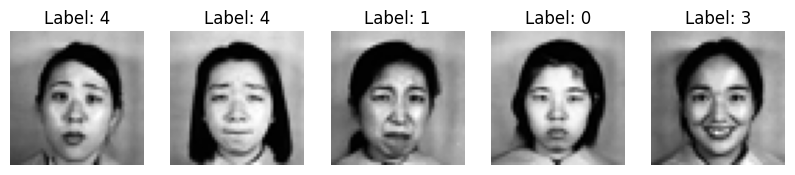

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

In [5]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (213, 900)


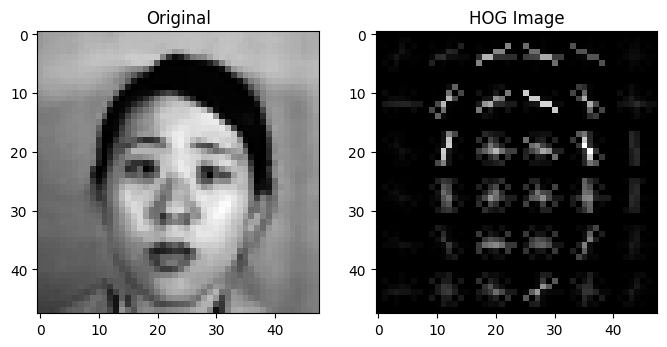

In [6]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, labels, test_size=0.3, random_state=42,shuffle=True
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_test = scaler.transform(X_test)         


model = SVC(kernel='linear')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

hog_acc = accuracy_score(y_test, y_pred)

print("HOG Accuracy:", hog_acc)

HOG Accuracy: 0.625


In [9]:
emotion_names = ['anger','disgust','fear','happy','sadness','surprise','neutral']
print(classification_report(y_test, y_pred, target_names=emotion_names))

              precision    recall  f1-score   support

       anger       1.00      0.36      0.53        11
     disgust       0.17      0.50      0.25         4
        fear       0.71      0.62      0.67         8
       happy       0.73      0.89      0.80         9
     sadness       0.42      0.71      0.53         7
    surprise       1.00      0.47      0.64        15
     neutral       0.82      0.90      0.86        10

    accuracy                           0.62        64
   macro avg       0.69      0.64      0.61        64
weighted avg       0.78      0.62      0.64        64



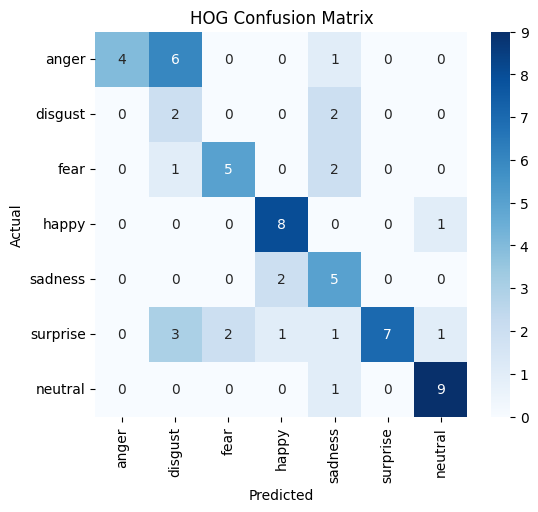

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("HOG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

cv_scores = cross_val_score(pipeline, X_hog, labels, cv=10)

print("\n=== 10-Fold CV ===")
print("Fold Accuracies:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))


=== 10-Fold CV ===
Fold Accuracies: [0.81818182 0.77272727 0.81818182 0.66666667 0.76190476 0.71428571
 0.76190476 0.85714286 0.66666667 0.9047619 ]
Mean Accuracy: 0.7742424242424243
Std Dev: 0.0740376816644986


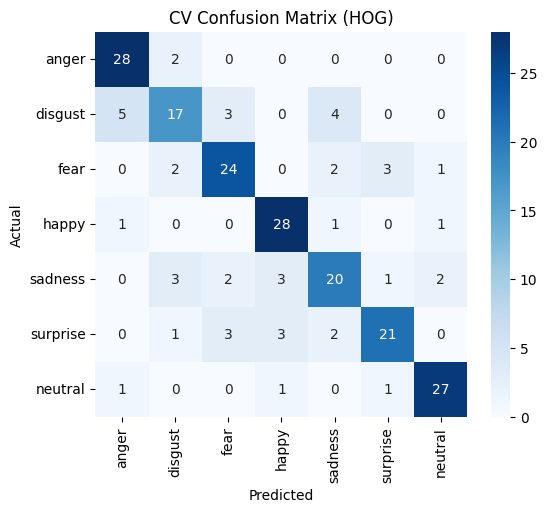

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# get predictions from CV
y_pred_cv = cross_val_predict(pipeline, X_hog, labels, cv=10)

# confusion matrix
cm = confusion_matrix(labels, y_pred_cv)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("CV Confusion Matrix (HOG)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [13]:

# classification report
print(classification_report(labels, y_pred_cv, target_names=emotion_names))

              precision    recall  f1-score   support

       anger       0.80      0.93      0.86        30
     disgust       0.68      0.59      0.63        29
        fear       0.75      0.75      0.75        32
       happy       0.80      0.90      0.85        31
     sadness       0.69      0.65      0.67        31
    surprise       0.81      0.70      0.75        30
     neutral       0.87      0.90      0.89        30

    accuracy                           0.77       213
   macro avg       0.77      0.77      0.77       213
weighted avg       0.77      0.77      0.77       213



In [14]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess


# Load pretrained model (feature extractor)
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# VGG
vgg = VGG16(weights='imagenet', include_top=False, pooling='avg')

2026-05-05 17:51:59.059766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778003519.282669      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778003519.346415      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778003519.844584      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778003519.844624      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778003519.844626      57 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
import cv2
import numpy as np

def extract_cnn_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = preprocess_input(img)
    
        img = np.expand_dims(img, axis=0)
        
        feat = model.predict(img, verbose=0)
        features.append(feat.flatten())
    
    return np.array(features)

In [16]:
def extract_vgg_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = vgg_preprocess(img)
        
        img = np.expand_dims(img, axis=0)
        feat = model.predict(img, verbose=0)
        
        features.append(feat.flatten())
    
    return np.array(features)

In [17]:
# MobileNet features
X_cnn = extract_cnn_features(data, mobilenet)

print("CNN feature shape:", X_cnn.shape)

I0000 00:00:1778003548.770258     132 service.cc:152] XLA service 0x784958004350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778003548.770311     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778003548.770318     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778003549.381811     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-05 17:52:37.480658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 17:52:37.614596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778003558.979964     132 device_co

CNN feature shape: (213, 1280)


In [18]:
# VGG features
X_vgg = extract_vgg_features(data, vgg)

print("VGG feature shape:", X_vgg.shape)

VGG feature shape: (213, 512)


In [19]:
# Hybrid CNN (VGG + MobileNet)
X_hybrid = np.concatenate([X_cnn, X_vgg], axis=1)

# HOG + Hybrid (final best)
X_final = np.concatenate([X_hog, X_hybrid], axis=1)

print("Hybrid shape:", X_hybrid.shape)
print("Final shape:", X_final.shape)

Hybrid shape: (213, 1792)
Final shape: (213, 2692)


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def run_model(X, name):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, labels,
        test_size=0.3,
        stratify=labels,
        random_state=42
    )
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear'))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"{name} Accuracy:", acc)
    
    return acc, y_test, y_pred

In [45]:
acc_hog, y_test_hog, y_pred_hog = run_model(X_hog, "HOG")

acc_cnn, y_test_cnn, y_pred_cnn = run_model(X_cnn, "MobileNet")

acc_vgg, y_test_vgg, y_pred_vgg = run_model(X_vgg, "VGG")

acc_hybrid, y_test_hybrid, y_pred_hybrid = run_model(X_hybrid, "Hybrid CNN")

HOG Accuracy: 0.65625
MobileNet Accuracy: 0.734375
VGG Accuracy: 0.71875
Hybrid CNN Accuracy: 0.765625


In [41]:
# import matplotlib.pyplot as plt

# models = ['HOG','MobileNet','VGG','Hybrid','HOG+Hybrid']
# scores = [acc_hog, acc_cnn, acc_vgg, acc_hybrid, acc_final]

# plt.figure(figsize=(7,4))
# bars = plt.bar(models, scores)

# plt.ylim(0,1)
# plt.title("JAFFE Only Model Comparison")
# plt.ylabel("Accuracy")

# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

# plt.xticks(rotation=20)
# plt.show()

In [25]:
# HOG + MobileNet
X_hog_cnn = np.concatenate([X_hog, X_cnn], axis=1)

# HOG + VGG
X_hog_vgg = np.concatenate([X_hog, X_vgg], axis=1)

print("HOG+CNN shape:", X_hog_cnn.shape)
print("HOG+VGG shape:", X_hog_vgg.shape)

HOG+CNN shape: (213, 2180)
HOG+VGG shape: (213, 1412)


In [46]:
acc_hog_cnn, y_test_hog_cnn, y_pred_hog_cnn = run_model(X_hog_cnn, "HOG + MobileNet")

acc_hog_vgg, y_test_hog_vgg, y_pred_hog_vgg = run_model(X_hog_vgg, "HOG + VGG")

acc_final, y_test_final, y_pred_final = run_model(X_final, "HOG + Hybrid")

HOG + MobileNet Accuracy: 0.75
HOG + VGG Accuracy: 0.765625
HOG + Hybrid Accuracy: 0.78125


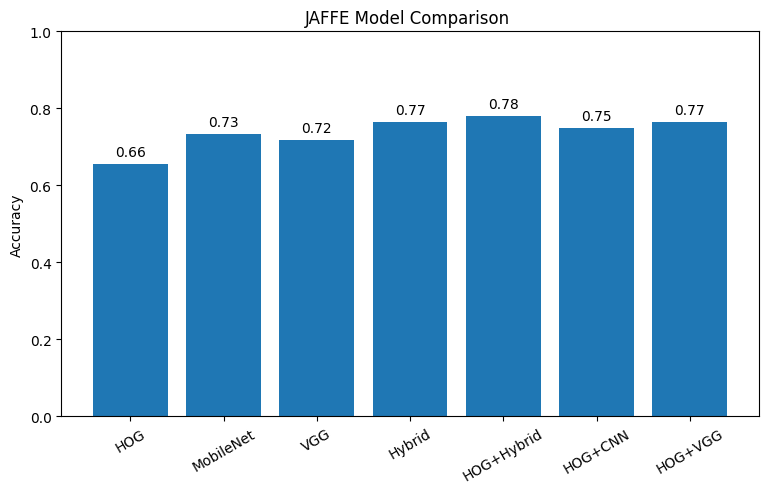

In [47]:
models = ['HOG','MobileNet','VGG','Hybrid','HOG+Hybrid','HOG+CNN','HOG+VGG']
scores = [
    acc_hog,
    acc_cnn,
    acc_vgg,
    acc_hybrid,
    acc_final,
    acc_hog_cnn,
    acc_hog_vgg
]

plt.figure(figsize=(9,5))
bars = plt.bar(models, scores)

plt.ylim(0,1)
plt.title("JAFFE Model Comparison ")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

plt.xticks(rotation=30)
plt.show()

In [31]:
from sklearn.model_selection import cross_val_score

# HOG + Hybrid (BEST)
cv_hog_hybrid = cross_val_score(pipeline, X_final, labels, cv=10)

# Hybrid CNN
cv_hybrid = cross_val_score(pipeline, X_hybrid, labels, cv=10)

# HOG + VGG
cv_hog_vgg = cross_val_score(pipeline, X_hog_vgg, labels, cv=10)

In [32]:
print("HOG+Hybrid CV Mean:", cv_hog_hybrid.mean(), "Std:", cv_hog_hybrid.std())
print("Hybrid CV Mean:", cv_hybrid.mean(), "Std:", cv_hybrid.std())
print("HOG+VGG CV Mean:", cv_hog_vgg.mean(), "Std:", cv_hog_vgg.std())

HOG+Hybrid CV Mean: 0.8961038961038963 Std: 0.09871648702157039
Hybrid CV Mean: 0.8727272727272727 Std: 0.08013804360287094
HOG+VGG CV Mean: 0.8683982683982684 Std: 0.1035790617225476


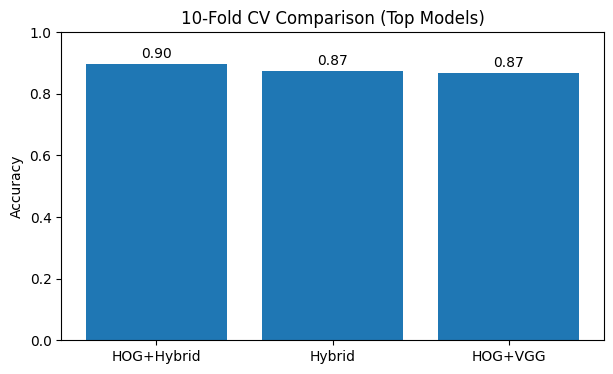

In [37]:
models = ['HOG+Hybrid', 'Hybrid', 'HOG+VGG']

means = [
    cv_hog_hybrid.mean(),
    cv_hybrid.mean(),
    cv_hog_vgg.mean()
]

plt.figure(figsize=(7,4))
bars = plt.bar(models, means, capsize=5)

plt.ylim(0,1)
plt.title("10-Fold CV Comparison (Top Models)")
plt.ylabel("Accuracy")

# values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

plt.show()

In [ ]:
# same thing on other 4 dataset
#  some images of different kind and checek wheather for which emotion algo is chceking something where 
# also check whether how it is distributed using np.unique 
# make a report of whatever we have done till now

# saturday evaluation meeting
